# Binary Classification

src: https://sagemaker-examples.readthedocs.io/en/latest/introduction_to_applying_machine_learning/xgboost_customer_churn/xgboost_customer_churn.html

In [1]:
import sys

!{sys.executable} -m pip install sagemaker pandas numpy --upgrade
!pip3 install -U sagemaker

  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)


In [26]:
import sagemaker

sess = sagemaker.Session()
bucket = sess.default_bucket()
prefix = "sagemaker/DEMO-xgboost-churn"

# Define IAM role
# boto3 is the official AWS SDK for Python.
# boto3 lets your Python code talk to AWS services like S3, SageMaker, etc.
import boto3

# re is Python's regular expression module.
# (FYI: it's not used in this snippet—safe to remove until you need it.)
import re

# get_execution_role is a SageMaker helper.
# When you run this code *inside* SageMaker (Studio/Notebook Instance),
# it returns the IAM Role ARN that the current environment is using.
# That role controls what AWS resources your code is allowed to access
# (for example, reading/writing S3, starting training jobs, creating endpoints).
from sagemaker import get_execution_role

# Ask SageMaker for the role of the *current* environment.
# Example return value:
# 'arn:aws:iam::123456789012:role/service-role/AmazonSageMaker-ExecutionRole-20250101T000001'
role = get_execution_role()

# (Optional) Peek at the role ARN to confirm.
# print(role)
# arn:aws:iam::<account_id> :role/SageMakerNotebookTestRole

# Typical usage:
# Pass `role` into SageMaker Estimators/Models so training/inference jobs
# inherit the same permissions. For example:
# xgb_estimator = sagemaker.xgboost.estimator.XGBoost(
#     entry_point="train.py",
#     role=role,
#     instance_count=1,
#     instance_type="ml.m5.xlarge"
# )


**Quick notes:**

* `get_execution_role()` only works when running inside a SageMaker-managed environment.
  If you run locally, you’ll need to set `role` to your SageMaker execution role ARN string manually (or use a different auth flow).
* That role should have permissions for the tasks you need (e.g., S3 access for data/model artifacts, launching training jobs, and reading logs).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import os
import sys
import time
import json
from IPython.display import display
from time import strftime, gmtime
from sagemaker.inputs import TrainingInput
from sagemaker.serializers import CSVSerializer

In [4]:
# S3 = Amazon Simple Storage Service. We'll use the boto3 S3 *client*
# to download a public demo dataset used in the SageMaker "XGBoost customer churn" example.

import boto3

# If you *already* have a SageMaker session as `sess`, keep using it.
# Otherwise, create one so we can grab the current AWS region.
# (SageMaker examples often use this `sess` name.)
try:
    sess  # do we already have it?
except NameError:
    import sagemaker
    sess = sagemaker.Session()  # binds to your default SageMaker/AWS setup

# This bucket hosts read-only example files. Its name includes your region,
# e.g., "sagemaker-example-files-prod-us-east-1"
bucket_name = f"sagemaker-example-files-prod-{sess.boto_region_name}"

# This is the file path (key) *inside* that S3 bucket.
# For the churn tutorial, the dataset lives under this prefix.
key = "datasets/tabular/synthetic/churn.txt"

# This is the *local* filename to save as.
local_path = "churn.txt"

# Create an S3 client (boto3 figures out credentials from your environment/role).
s3 = boto3.client("s3")

# Download the file:
#   arg1 = bucket name in S3
#   arg2 = object key (path within the bucket)
#   arg3 = local file path to write to
s3.download_file(bucket_name, key, local_path)

print(f"Downloaded s3://{bucket_name}/{key} -> {local_path}")


Downloaded s3://sagemaker-example-files-prod-us-east-1/datasets/tabular/synthetic/churn.txt -> churn.txt


In [5]:
churn = pd.read_csv("./churn.txt")
pd.set_option("display.max_columns", 500)
churn

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,PA,163,806,403-2562,no,yes,300,8.162204,3,7.579174,3.933035,4,6.508639,4.065759,100,5.111624,4.928160,6,5.673203,3,True.
1,SC,15,836,158-8416,yes,no,0,10.018993,4,4.226289,2.325005,0,9.972592,7.141040,200,6.436188,3.221748,6,2.559749,8,False.
2,MO,131,777,896-6253,no,yes,300,4.708490,3,4.768160,4.537466,3,4.566715,5.363235,100,5.142451,7.139023,2,6.254157,4,False.
3,WY,75,878,817-5729,yes,yes,700,1.268734,3,2.567642,2.528748,5,2.333624,3.773586,450,3.814413,2.245779,6,1.080692,6,False.
4,WY,146,878,450-4942,yes,no,0,2.696177,3,5.908916,6.015337,3,3.670408,3.751673,250,2.796812,6.905545,4,7.134343,6,True.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,NH,4,787,151-3162,yes,yes,800,10.862632,5,7.250969,6.936164,1,8.026482,4.921314,350,6.748489,4.872570,8,2.122530,9,False.
4996,SD,140,836,351-5993,no,no,0,1.581127,8,3.758307,7.377591,7,1.328827,0.939932,300,4.522661,6.938571,2,4.600473,4,False.
4997,SC,32,836,370-3127,no,yes,700,0.163836,5,4.243980,5.841852,3,2.340554,0.939469,450,5.157898,4.388328,7,1.060340,6,False.
4998,MA,142,776,604-2108,yes,yes,600,2.034454,5,3.014859,4.140554,3,3.470372,6.076043,150,4.362780,7.173376,3,4.871900,7,True.


## Feature Descriptions

- **State**: The US state in which the customer resides, indicated by a two-letter abbreviation (e.g., `OH`, `NJ`).
- **Account Length**: Number of days that this account has been active.
- **Area Code**: The three-digit area code of the customer's phone number.
- **Phone**: The remaining seven-digit phone number.
- **Int’l Plan**: Whether the customer has an international calling plan (`yes` / `no`).
- **VMail Plan**: Whether the customer has a voice mail feature (`yes` / `no`).
- **VMail Message**: The average number of voice mail messages per month.
- **Day Mins**: Total number of calling minutes used during the day.
- **Day Calls**: Total number of calls placed during the day.
- **Day Charge**: The billed cost of daytime calls.
- **Eve Mins**, **Eve Calls**, **Eve Charge**: Evening calling minutes, number of evening calls, and billed cost for evening calls.
- **Night Mins**, **Night Calls**, **Night Charge**: Nighttime calling minutes, number of nighttime calls, and billed cost for nighttime calls.
- **Intl Mins**, **Intl Calls**, **Intl Charge**: International calling minutes, number of international calls, and billed cost for international calls.
- **CustServ Calls**: Number of calls placed to Customer Service.
- **Churn?**: Whether the customer left the service (`true` / `false`).

## Frequency tables for each categorical feature

In [6]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           5000 non-null   object 
 1   Account Length  5000 non-null   int64  
 2   Area Code       5000 non-null   int64  
 3   Phone           5000 non-null   object 
 4   Int'l Plan      5000 non-null   object 
 5   VMail Plan      5000 non-null   object 
 6   VMail Message   5000 non-null   int64  
 7   Day Mins        5000 non-null   float64
 8   Day Calls       5000 non-null   int64  
 9   Day Charge      5000 non-null   float64
 10  Eve Mins        5000 non-null   float64
 11  Eve Calls       5000 non-null   int64  
 12  Eve Charge      5000 non-null   float64
 13  Night Mins      5000 non-null   float64
 14  Night Calls     5000 non-null   int64  
 15  Night Charge    5000 non-null   float64
 16  Intl Mins       5000 non-null   float64
 17  Intl Calls      5000 non-null   i

## Exploratory Data Audit: Categorical Distributions, Numeric Summary, and Histograms (Churn Dataset)

## Why run this?

* **Sanity-check the data**: confirm dtypes, ranges, and that values look plausible before modeling.
* **Plan preprocessing**: decide how to encode categoricals, whether to group rare labels, and if numeric features need transforms (log, clipping).
* **Spot issues early**: detect dominant/rare categories, missing/“unknown” tokens, outliers, skew, and inconsistent scales.

## What can you find?

* **Categorical profile (crosstab)**

  * The **share of each category** within a feature (e.g., `Contract = month-to-month` might dominate).
  * **High cardinality** columns (too many unique values) that may need grouping or target/frequency encoding.
  * **Rare categories** to combine into “Other” to stabilize models.
  * **Placeholders** like `"unknown"`/`"N/A"` that signal missingness you might encode explicitly.

* **Numeric summary (`describe()`)**

  * **Central tendency & spread** (mean, std) to understand typical values and variability.
  * **Range & quartiles** (min/25%/50%/75%/max) to flag **outliers** and **skew**.
  * **Scale differences** across features (some might be in hundreds, others in fractions) that can affect certain models; XGBoost is robust to scaling but skew/outliers can still matter.

* **Histograms (all numeric columns)**

  * **Distribution shape**: normal, skewed, multimodal, or zero-inflated.
  * **Heavy tails/outliers** suggesting winsorization or log transform.
  * **Comparability** via `sharey=True`, letting you visually gauge which features vary more.

### Typical follow-ups

* **Categoricals**: one-hot encode (k vs. k−1), combine rare levels, or try frequency/target encoding (with CV).
* **Numerics**: handle missing values, consider log/Box-Cox for skewed features, cap extreme outliers.
* **Modeling**: feed the cleaned dataset to the SageMaker XGBoost flow from the churn tutorial (train/validation split, tune hyperparameters, evaluate).


### Create a cross-tabulation table

In [7]:
# Loop through each column in the DataFrame 'churn' that has data type "object" (i.e., text or categorical variables)
for column in churn.select_dtypes(include=["object"]).columns:
    # Create a cross-tabulation table showing the proportion (% observations) of each category in the column
    # 'index' is the unique values in the column
    # 'columns' is a single label "% observations"
    # normalize="columns" converts counts into percentages
    display(pd.crosstab(index=churn[column], columns="% observations", normalize="columns"))

col_0,% observations
State,
AK,0.0170
AL,0.0200
AR,0.0220
AZ,0.0180
CA,0.0208
CO,0.0182
CT,0.0178
DC,0.0224
DE,0.0182


col_0,% observations
Phone,
100-2030,0.0002
100-2118,0.0002
100-3505,0.0002
100-5224,0.0002
101-3371,0.0002
...,...
999-3178,0.0002
999-5498,0.0002
999-5816,0.0002


col_0,% observations
Int'l Plan,
no,0.5014
yes,0.4986


col_0,% observations
VMail Plan,
no,0.4976
yes,0.5024


col_0,% observations
Churn?,
False.,0.5004
True.,0.4996


### Show basic statistical summary for all numeric columns in the dataset

In [8]:
# Show basic statistical summary for all numeric columns in the dataset
# Includes count, mean, std, min, 25%, 50% (median), 75%, and max values
display(churn.describe())

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,101.675800,773.791400,226.680000,5.518757,3.50460,5.018902,5.026199,3.140400,5.017557,4.000917,224.790000,5.023490,5.025876,5.475400,4.328242,5.525800
std,57.596762,63.470888,273.998527,3.433485,1.68812,2.195759,2.135487,2.525621,2.127857,1.631001,97.302875,1.748900,1.019302,1.877045,2.440311,2.041217
min,1.000000,657.000000,0.000000,0.000215,0.00000,0.004777,0.004659,0.000000,0.013573,0.008468,0.000000,0.054863,1.648514,0.000000,0.000769,0.000000
25%,52.000000,736.000000,0.000000,2.682384,2.00000,3.470151,3.588466,1.000000,3.529613,2.921998,150.000000,3.873157,4.349726,4.000000,2.468225,4.000000
50%,102.000000,778.000000,0.000000,5.336245,3.00000,4.988291,5.145656,3.000000,5.006860,3.962089,200.000000,5.169154,5.034905,5.000000,4.214058,6.000000
75%,151.000000,806.000000,400.000000,7.936151,5.00000,6.559750,6.552962,5.000000,6.491725,5.100128,300.000000,6.272015,5.716386,7.000000,5.960654,7.000000
max,200.000000,878.000000,1300.000000,16.897529,10.00000,12.731936,13.622097,14.000000,12.352871,10.183378,550.000000,10.407778,8.405644,12.000000,14.212261,13.000000


### Create histograms for all numeric features in 'churn'

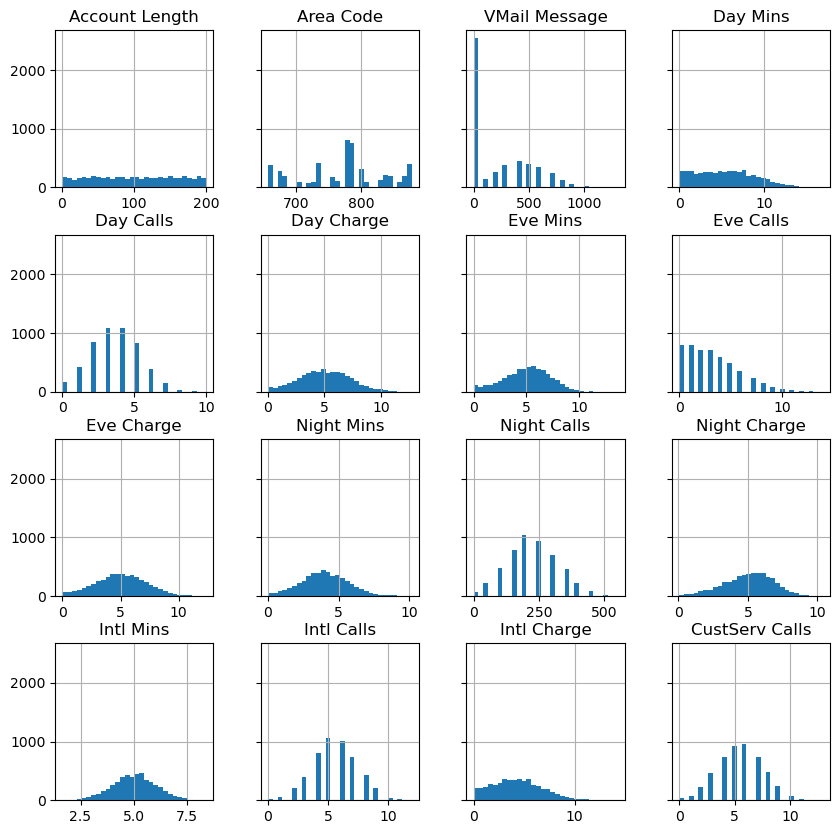

In [9]:
# This magic command makes matplotlib plots appear directly inside the Jupyter Notebook
%matplotlib inline

# Create histograms for all numeric features in 'churn'
# bins=30 means each histogram will have 30 bars (intervals)
# sharey=True makes all histograms share the same Y-axis scale for easier comparison
# figsize sets the size of the plot (width=10 inches, height=10 inches)
hist = churn.hist(bins=30, sharey=True, figsize=(10, 10))

### Observations

1. State is evenly distributed
2. Phone takes on too many unique values to be of any practical use. It’s possible that parsing out the prefix could have some value, but without more context on how these are allocated, we should avoid using it
3. Many of the features nicely distributed showing Normal (Guassian) distribution
4. VMail Message is a notable exception
5. Area Code is a label, not a quantity—encode it as categorical so models learn separate effects per code rather than a fake numeric trend

In [10]:
# Drop the 'Phone' column because it's an identifier (not predictive). 
# axis=1 specifies we’re dropping a COLUMN (axis=0 would mean a row).
churn = churn.drop("Phone", axis=1)

# Treat 'Area Code' as categorical/text instead of numeric so models don’t infer fake order.
# 'object' forces non-numeric behavior. (If available in your pandas version, prefer 'string'.)
churn["Area Code"] = churn["Area Code"].astype(object)     # or: .astype("string")

## Look at the relationship between each of the features and our target variable

In [11]:
# Prerequisites for this snippet:
# import pandas as pd
# import matplotlib.pyplot as plt

# Loop over all *categorical/text* columns (dtype 'object') in the churn DataFrame
for column in churn.select_dtypes(include=["object"]).columns:
    # Skip the target column to avoid a trivial crosstab
    if column != "Churn?":
        # Build a contingency table of Category (rows) vs Churn class (columns).
        # normalize="columns" => each column sums to 1.0
        # i.e., it shows P(category | given churn class), which is great for comparing classes
        display(pd.crosstab(index=churn[column],
                            columns=churn["Churn?"],
                            normalize="columns"))

Churn?,False.,True.
State,,
AK,0.015588,0.018415
AL,0.021583,0.018415
AR,0.022782,0.021217
AZ,0.015588,0.020416
CA,0.020384,0.021217
CO,0.018785,0.017614
CT,0.015588,0.020016
DC,0.022382,0.022418
DE,0.018385,0.018014


Churn?,False.,True.
Area Code,,
657,0.037170,0.036829
658,0.022782,0.021217
659,0.015588,0.020416
676,0.020384,0.021217
677,0.018785,0.017614
678,0.015588,0.020016
686,0.040767,0.040432
707,0.019984,0.015612
716,0.017986,0.015212


Churn?,False.,True.
Int'l Plan,,
no,0.5,0.502802
yes,0.5,0.497198


Churn?,False.,True.
VMail Plan,,
no,0.496403,0.498799
yes,0.503597,0.501201


Account Length


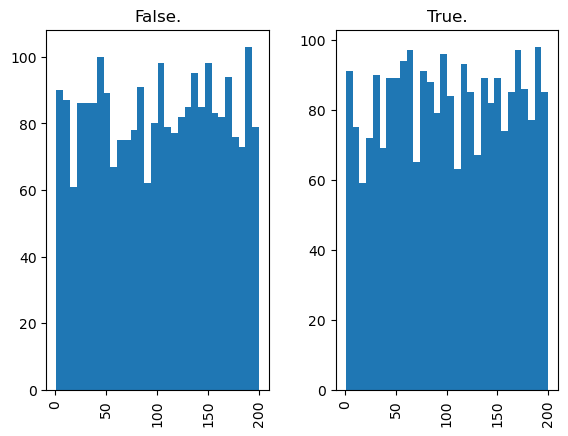

VMail Message


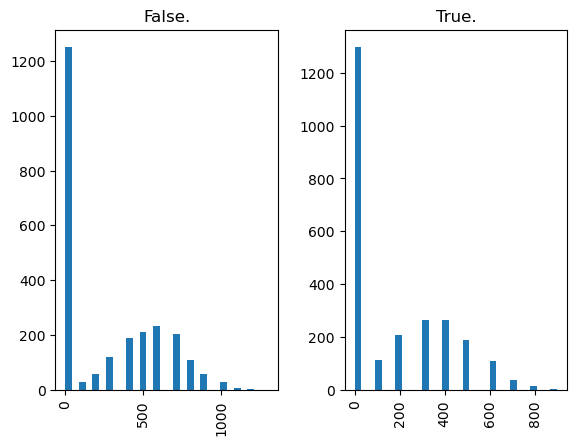

Day Mins


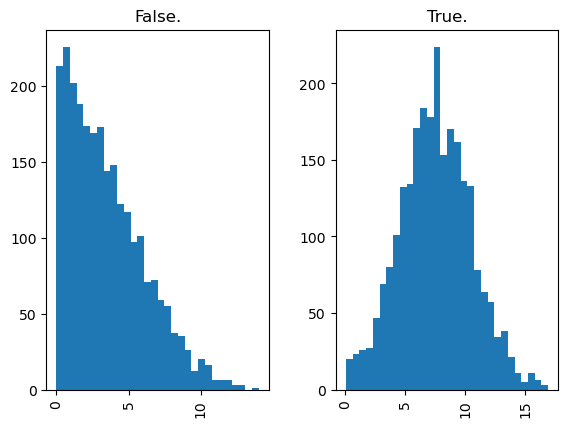

Day Calls


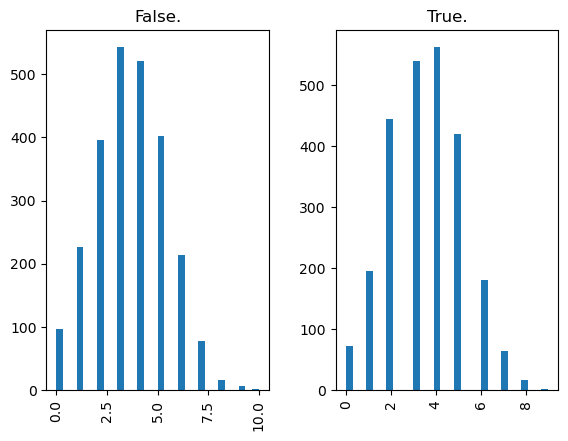

Day Charge


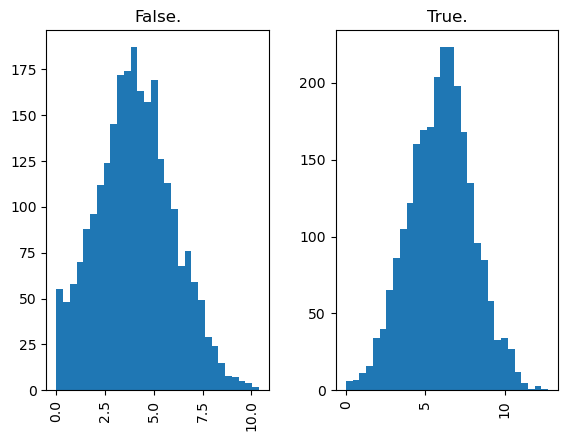

Eve Mins


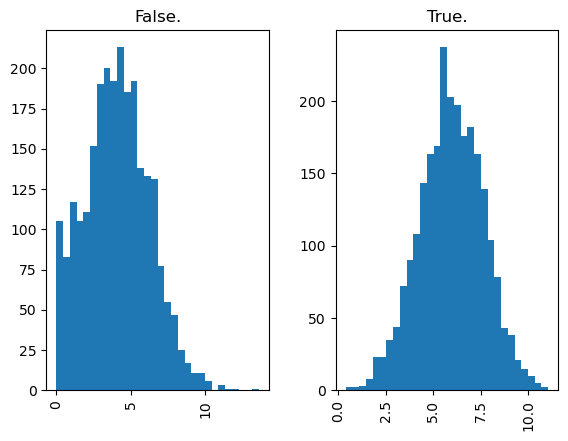

Eve Calls


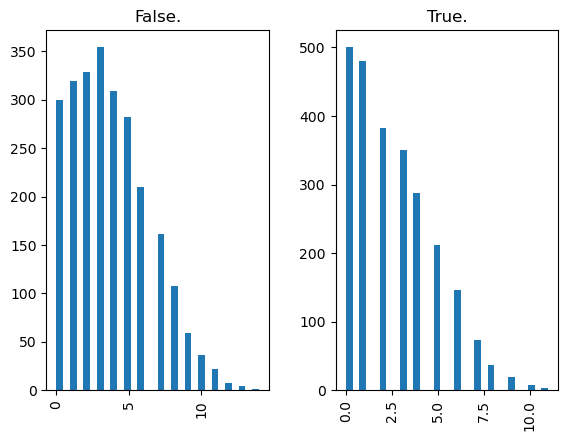

Eve Charge


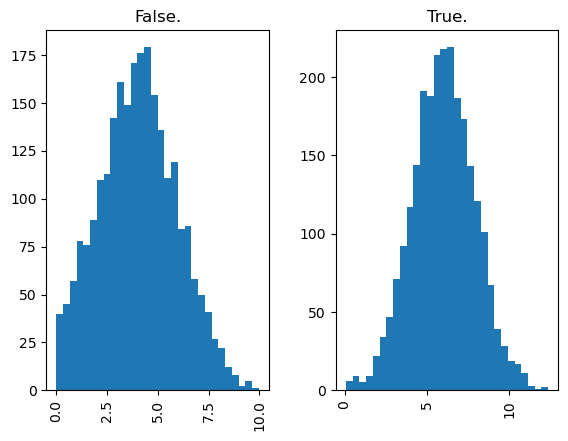

Night Mins


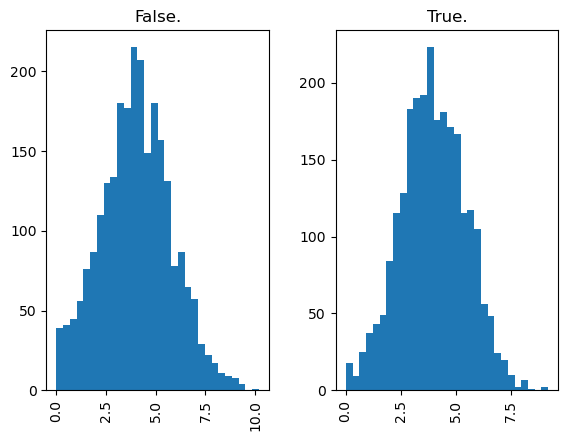

Night Calls


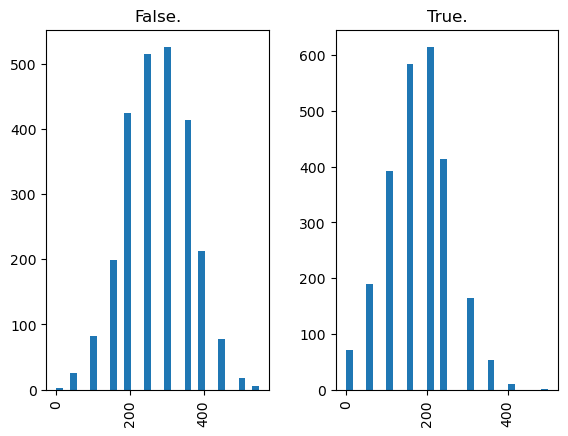

Night Charge


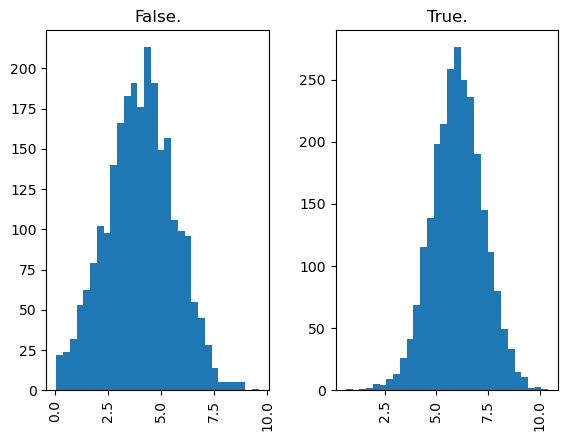

Intl Mins


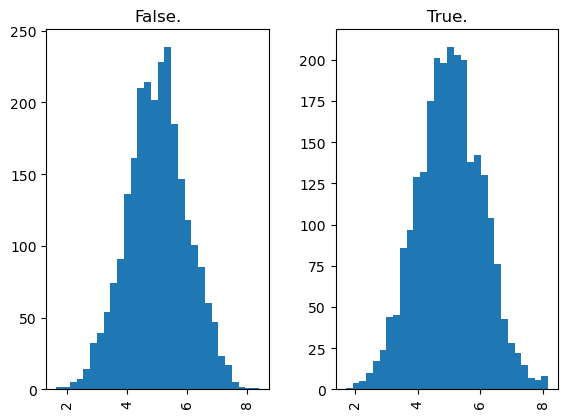

Intl Calls


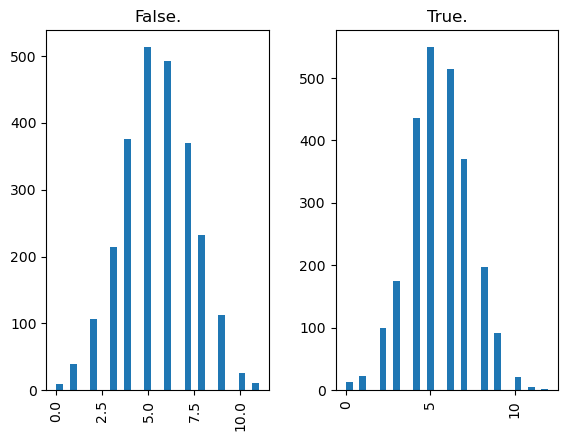

Intl Charge


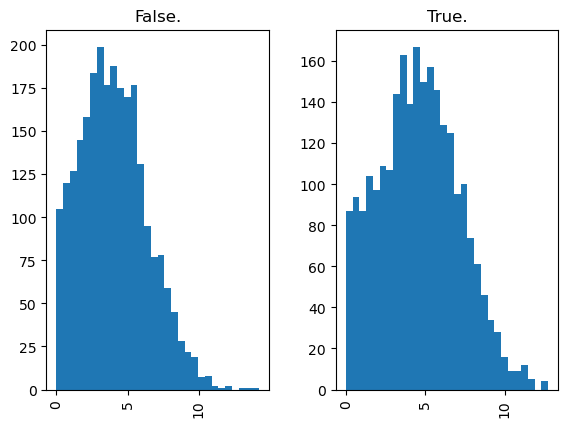

CustServ Calls


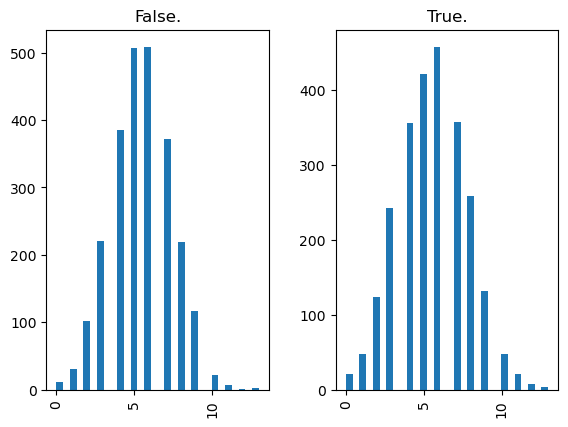

In [13]:
# Now loop over all *numeric* columns (everything not dtype 'object')
for column in churn.select_dtypes(exclude=["object"]).columns:
    print(column)  # Let us know which feature we’re plotting

    # Plot separate histograms of this numeric feature for each churn class side-by-side.
    # 'by="Churn?"' splits the data into one panel per class; bins=30 gives a detailed view.
    hist = churn[[column, "Churn?"]].hist(by="Churn?", bins=30)

    # Ensure the figures render in notebooks and move to the next plot cleanly
    plt.show()


### Pearson correlation matrix between all numeric columns.

**Purpose:** shows the **Pearson correlation matrix** between all numeric columns.
**Why it helps:**

* **Multicollinearity check:** flags pairs of highly correlated features (e.g., “minutes” vs. “charge” features), which can destabilize linear/logistic models and inflate variance. You might drop one of a near-duplicate pair.
* **Signal hunt (with a caveat):** if you encode the target as numeric, you can eyeball which features are **linearly associated** with churn. (Correlation ≠ causation and only captures linear relations.)
* **Data sanity:** unexpected 1.0 or −1.0 values can reveal derived/duplicate columns.

> Note: `numeric_only=True` excludes object/categorical columns (and your `Churn?` target if it’s still a string). If you want the target included:

```python
churn['churn_flag'] = (churn['Churn?'] == 'True.').astype(int)
display(churn.corr(numeric_only=True))
```

(For a binary target, this is the **point-biserial** correlation, equivalent to Pearson on {0,1}.)

In [12]:
display(churn.corr(numeric_only=True))

,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
Account Length,1.000000,-0.009030,-0.015878,0.011659,-0.007468,0.000213,0.026515,-0.012795,0.016400,-0.002383,-0.034925,0.017277,-0.003735,0.028285,-0.036721
VMail Message,-0.009030,1.000000,-0.143272,0.002762,-0.182712,-0.104667,-0.101240,-0.029212,0.061370,0.135042,-0.155475,-0.015162,0.131964,0.010120,0.068657
Day Mins,-0.015878,-0.143272,1.000000,-0.087598,0.667941,0.482641,-0.184939,0.766489,0.188190,-0.445212,0.570508,0.001988,0.236131,0.239331,-0.195322
Day Calls,0.011659,0.002762,-0.087598,1.000000,-0.222556,0.033903,0.185881,-0.052051,-0.085222,-0.083050,0.046641,-0.022548,-0.045671,-0.120064,-0.065518
Day Charge,-0.007468,-0.182712,0.667941,-0.222556,1.000000,0.574697,0.236626,0.371580,0.150700,-0.130722,0.374861,0.010294,0.119584,0.251748,-0.260945
Eve Mins,0.000213,-0.104667,0.482641,0.033903,0.574697,1.000000,-0.067123,0.269980,-0.090515,0.067315,0.317481,-0.015678,0.070456,0.448910,-0.167347
Eve Calls,0.026515,-0.101240,-0.184939,0.185881,0.236626,-0.067123,1.000000,-0.467814,0.221439,0.218149,-0.324936,-0.001593,-0.112062,0.017036,-0.433467
Eve Charge,-0.012795,-0.029212,0.766489,-0.052051,0.371580,0.269980,-0.467814,1.000000,0.184230,-0.454649,0.546137,-0.003569,0.164104,0.243936,-0.011019
Night Mins,0.016400,0.061370,0.188190,-0.085222,0.150700,-0.090515,0.221439,0.184230,1.000000,-0.223023,-0.140482,-0.012781,0.038831,0.271179,-0.332802
Night Calls,-0.002383,0.135042,-0.445212,-0.083050,-0.130722,0.067315,0.218149,-0.454649,-0.223023,1.000000,-0.390333,-0.009821,0.181237,-0.155736,0.110211


### Plot scatter matrix

**Purpose:** creates a **pairwise scatter-plot grid** of numeric features (histograms on the diagonal).
**Why it helps:**

* **Non-linear patterns & clusters:** reveals relationships a correlation matrix can miss (curves, heteroskedasticity, clusters).
* **Outliers:** easy to spot extreme points across feature pairs.
* **Feature engineering ideas:** suggests interactions, transforms (e.g., log), or binning.

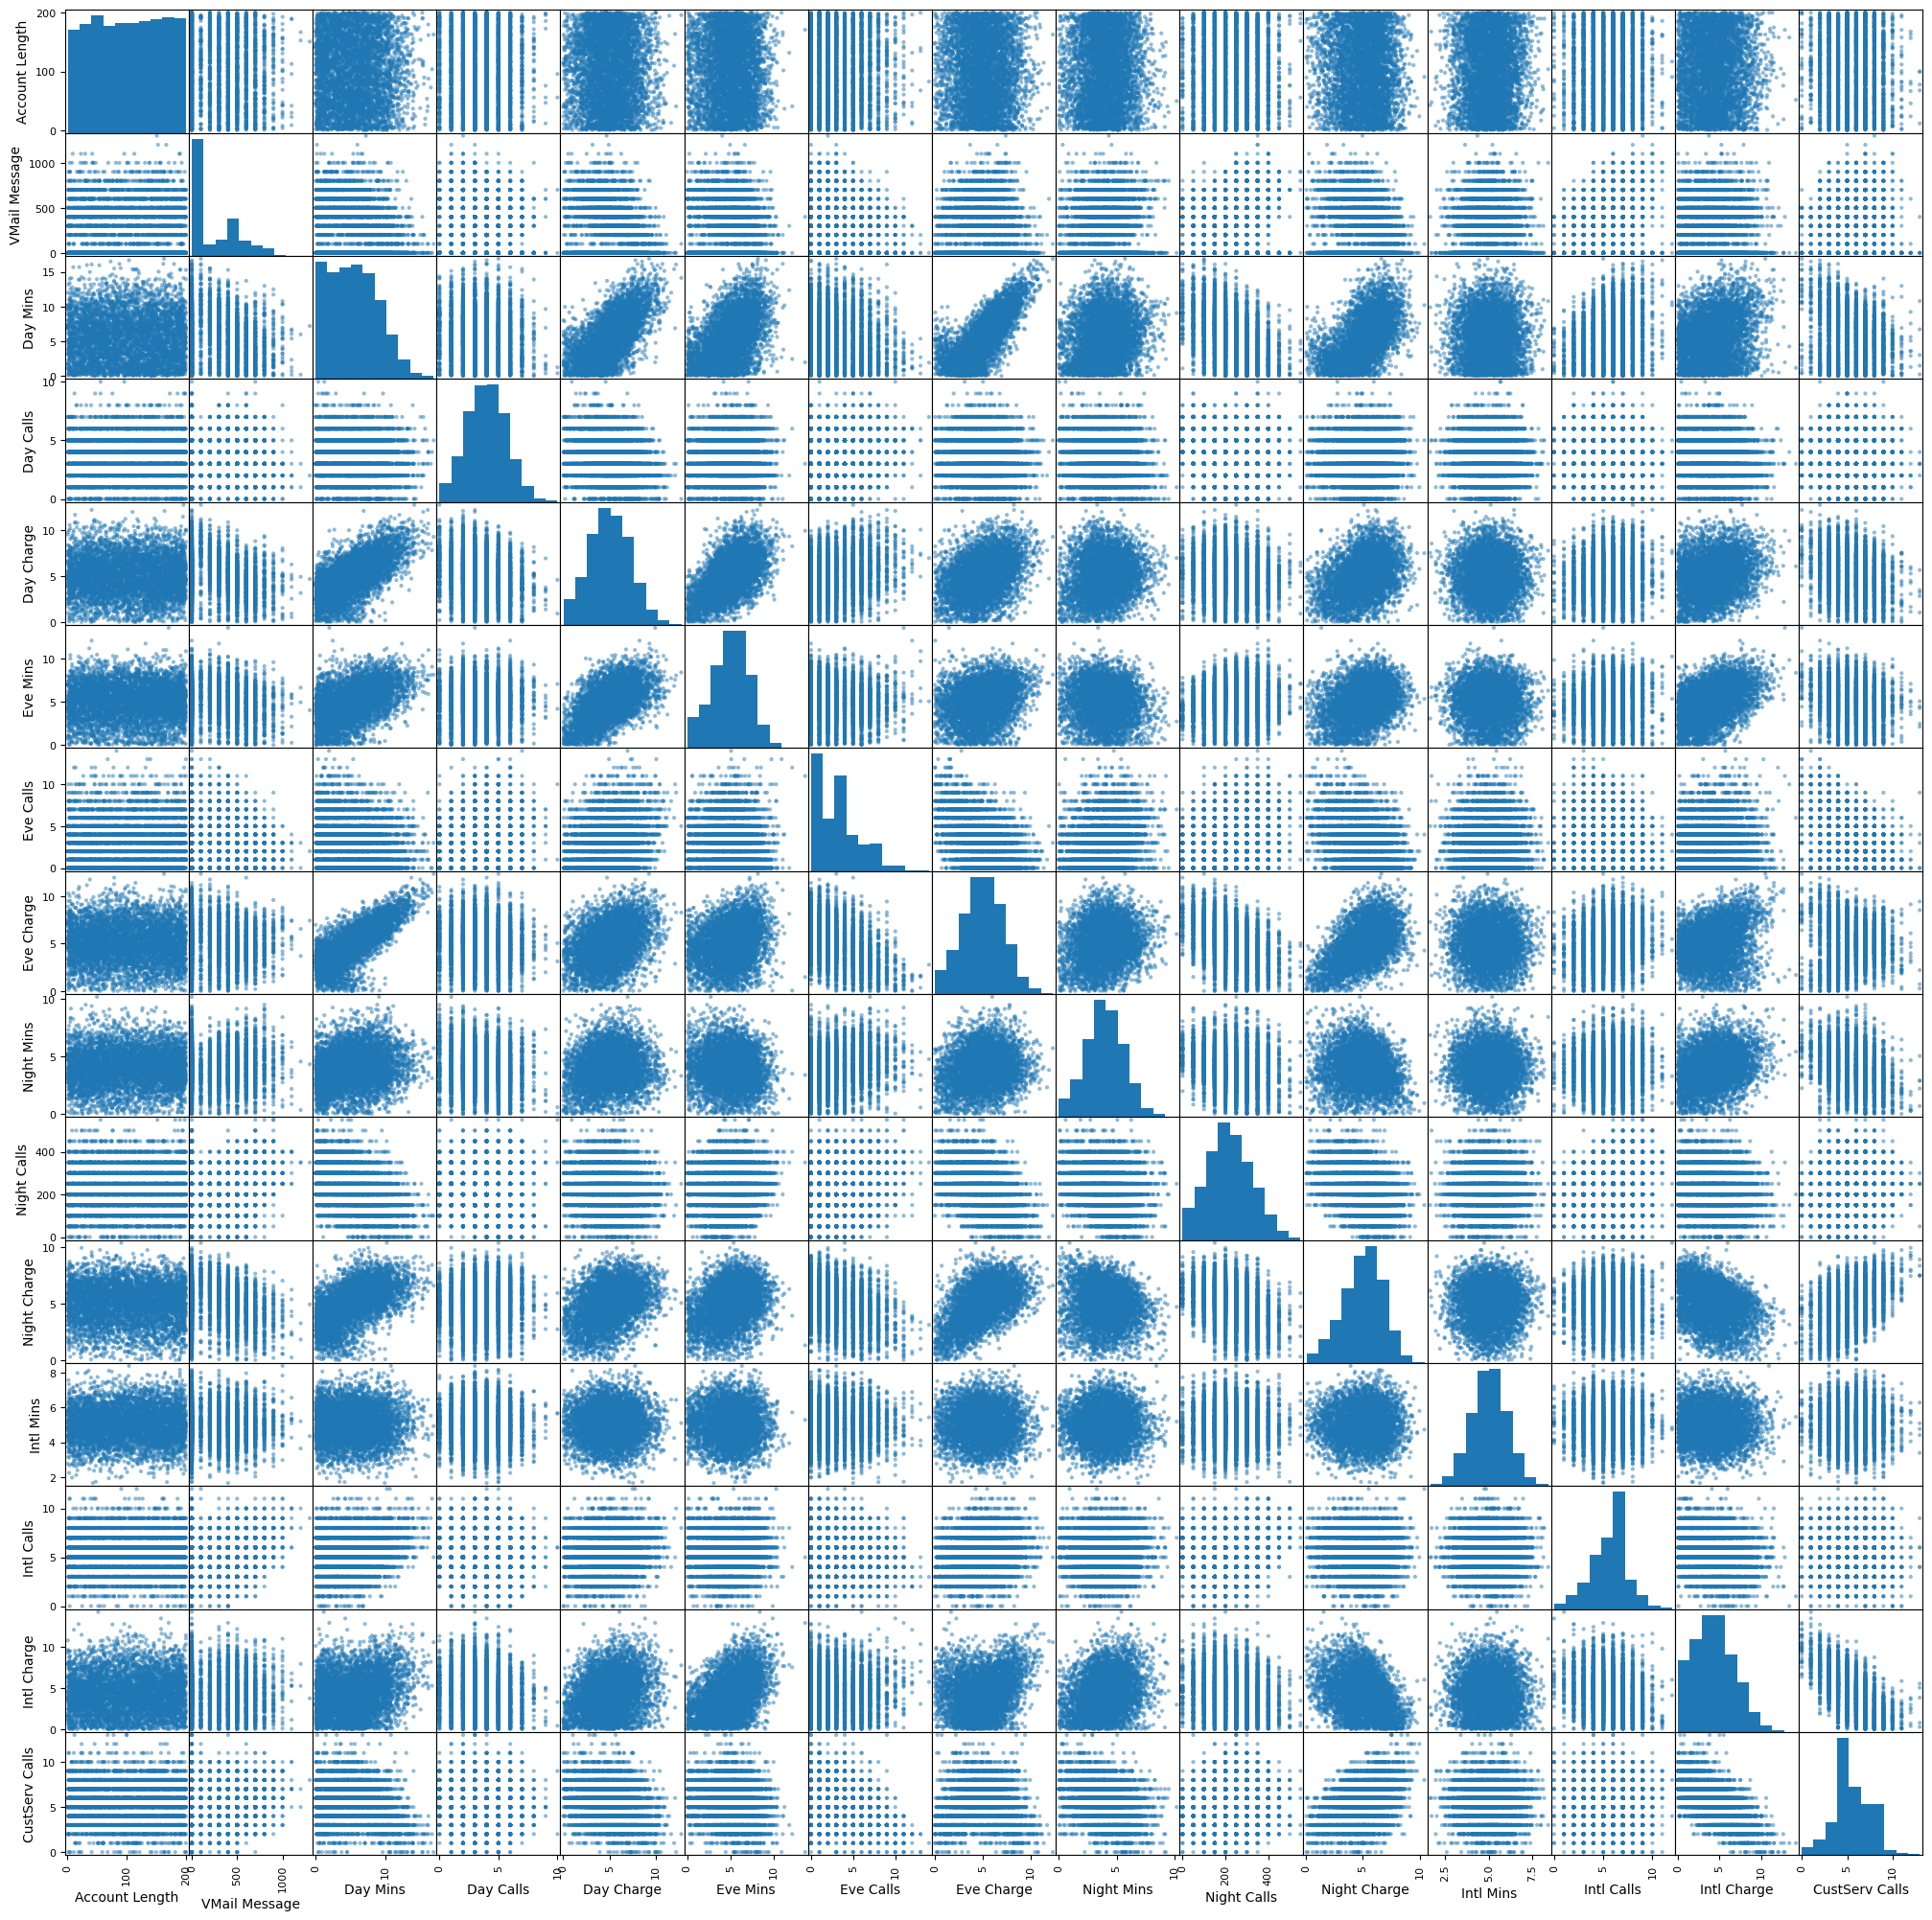

In [18]:
pd.plotting.scatter_matrix(churn, figsize=(25, 25))
plt.show()

**Make it more informative (optional):** color points by churn class and reduce overplotting:

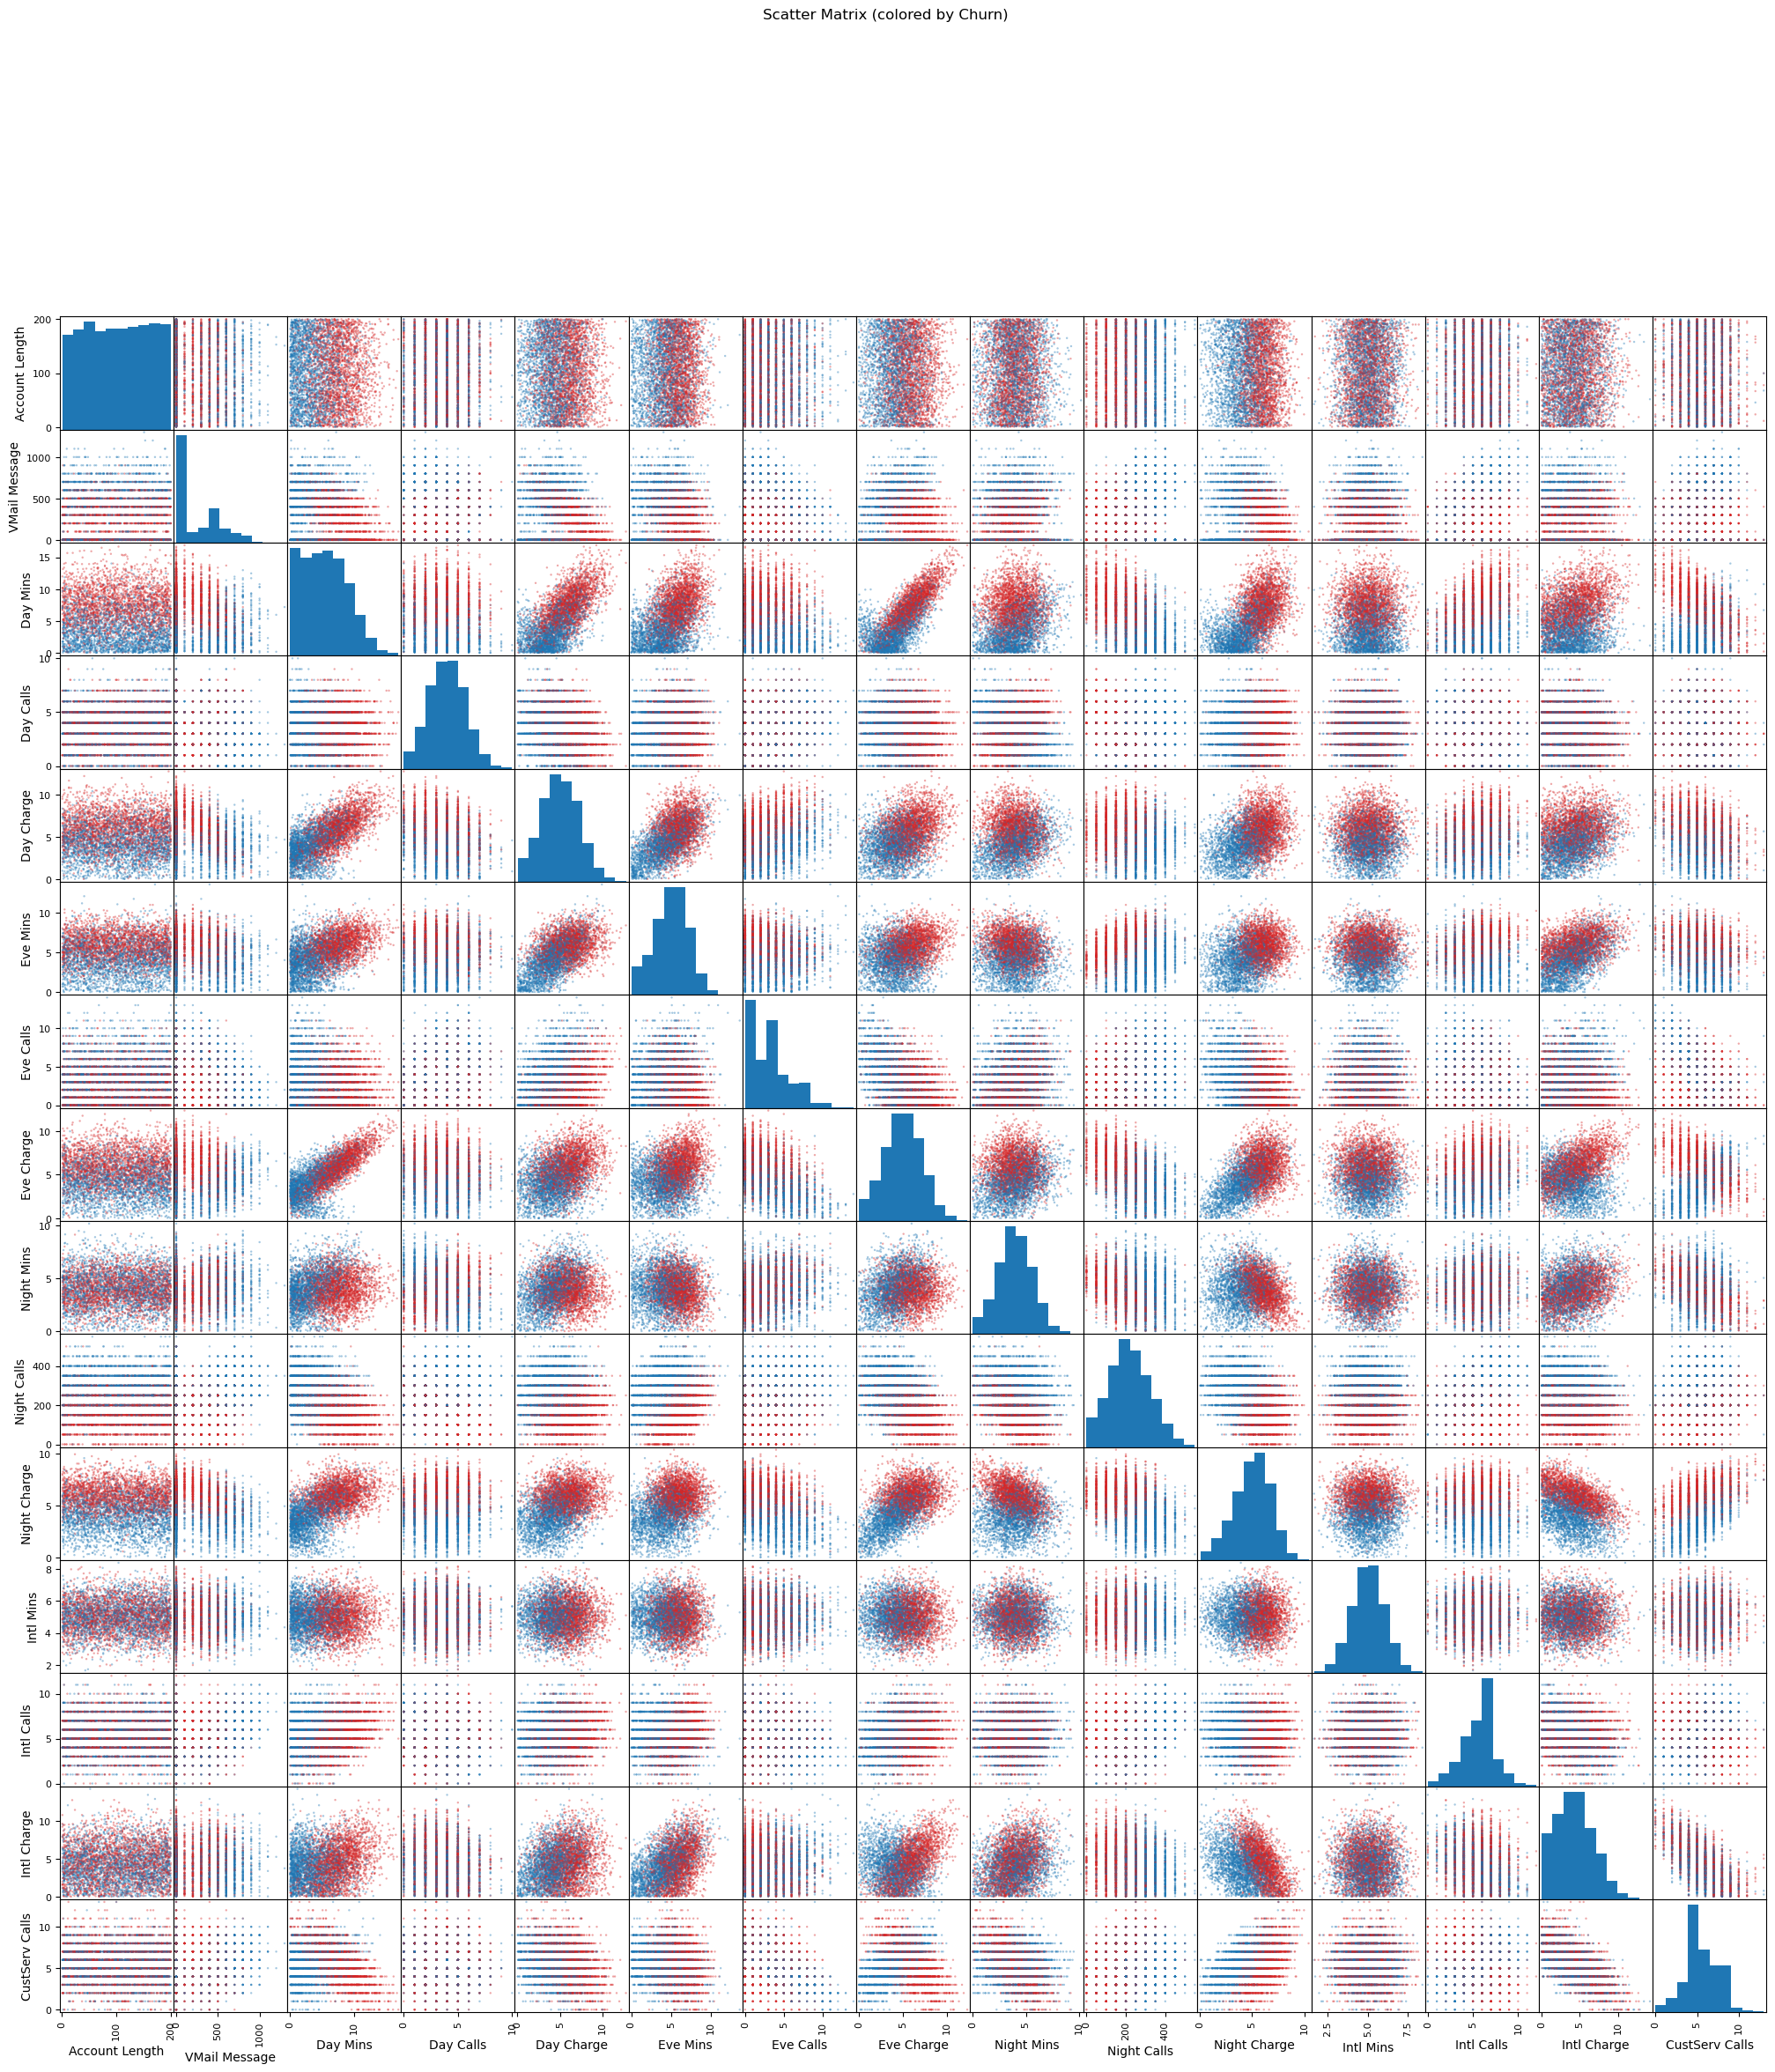

In [13]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

num = churn.select_dtypes(exclude=['object']).copy()
colors = churn['Churn?'].map({'True.':'tab:red','False.':'tab:blue'}).to_numpy()

axes = scatter_matrix(num, figsize=(25,25), diagonal='hist', c=colors, alpha=0.4, s=12)
plt.suptitle('Scatter Matrix (colored by Churn)', y=1.02)
plt.show()

**Practical tips**

* On wide datasets, compute the matrix on a **subset of important features** or a **row sample** to keep it readable.
* For tree models like XGBoost, multicollinearity isn’t a correctness issue, but **redundant features** can still slow training and add noise.

### Remove one feature from each of the highly correlated pairs

***Correlation Strength Guide (Pearson’s r)***

Use the absolute value (|r|) for strength; the sign only indicates direction.

| Amount of r (\|r\|) | Strength of correlation |
| :------------------ | :---------------------- |
| 0.0 to < 0.1        | no correlation          |
| 0.1 to < 0.3        | low correlation         |
| 0.3 to < 0.5        | medium correlation      |
| 0.5 to < 0.7        | high correlation        |
| 0.7 to < 1.0        | very high correlation   |

`Day Charge` from the pair with `Day Mins`; `Night Charge` from the pair with `Night Mins`; `Intl Charge` from the pair with `Intl Mins`

**Correlation ~ 1.0 means linear duplicate (positive scale)**

In [14]:
churn[['Day Mins','Day Charge']].corr()

,Day Mins,Day Charge
Day Mins,1.000000,0.667941
Day Charge,0.667941,1.000000


In [15]:
churn[['Night Mins','Night Charge']].corr()

,Night Mins,Night Charge
Night Mins,1.000000,-0.140482
Night Charge,-0.140482,1.000000


In [16]:
churn[['Intl Mins','Intl Charge']].corr()

,Intl Mins,Intl Charge
Intl Mins,1.000000,-0.010907
Intl Charge,-0.010907,1.000000


We therefore drop `Day Charge` from the pair with `Day Mins`; `Night Charge` from the pair with `Night Mins`; `Intl Charge` from the pair with `Intl Mins`

In [17]:
churn = churn.drop(["Day Charge", "Eve Charge", "Night Charge", "Intl Charge"], axis=1)

**XGBoost** uses gradient boosted trees which naturally account for 
1. non-linear relationships between **features and the target variable**,
2. as well as accommodating **complex interactions between features**.

### Convert our categorical features into numeric features

In [18]:
# 1) One-hot encode all categorical columns (including the target "Churn?")
#    - Converts strings to 0/1 indicator columns, e.g., "Area Code_408".
#    - By default, get_dummies keeps ALL levels (no drop_first), so a binary target becomes two columns.
model_data = pd.get_dummies(churn)
model_data

,Account Length,VMail Message,Day Mins,Day Calls,Eve Mins,Eve Calls,Night Mins,Night Calls,Intl Mins,Intl Calls,CustServ Calls,State_AK,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Area Code_657,Area Code_658,Area Code_659,Area Code_676,Area Code_677,Area Code_678,Area Code_686,Area Code_707,Area Code_716,Area Code_727,Area Code_736,Area Code_737,Area Code_758,Area Code_766,Area Code_776,Area Code_777,Area Code_778,Area Code_786,Area Code_787,Area Code_788,Area Code_797,Area Code_798,Area Code_806,Area Code_827,Area Code_836,Area Code_847,Area Code_848,Area Code_858,Area Code_866,Area Code_868,Area Code_876,Area Code_877,Area Code_878,Int'l Plan_no,Int'l Plan_yes,VMail Plan_no,VMail Plan_yes,Churn?_False.,Churn?_True.
0,163,300,8.162204,3,3.933035,4,4.065759,100,4.928160,6,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
1,15,0,10.018993,4,2.325005,0,7.141040,200,3.221748,6,8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,True,False
2,131,300,4.708490,3,4.537466,3,5.363235,100,7.139023,2,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False
3,75,700,1.268734,3,2.528748,5,3.773586,450,2.245779,6,6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,True,False
4,146,0,2.696177,3,6.015337,3,3.751673,250,6.905545,4,6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

In [19]:
# 2) Make the binary target the first column and remove the redundant target dummy:
#    - Keep only "Churn?_True." as the label (1 = churned, 0 = did not churn).
#    - Drop both "Churn?_False." and "Churn?_True." from the FEATURES to avoid duplicate target columns,
#      then prepend the kept target column to the front.
#    - NOTE: Adjust the literal names if your dataset spells the labels differently (e.g., "True" vs "True.").
model_data = pd.concat(
    [
        model_data["Churn?_True."],                                 # target y
        model_data.drop(["Churn?_False.", "Churn?_True."], axis=1)  # all features X
    ],
    axis=1
)
model_data

,Churn?_True.,Account Length,VMail Message,Day Mins,Day Calls,Eve Mins,Eve Calls,Night Mins,Night Calls,Intl Mins,Intl Calls,CustServ Calls,State_AK,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Area Code_657,Area Code_658,Area Code_659,Area Code_676,Area Code_677,Area Code_678,Area Code_686,Area Code_707,Area Code_716,Area Code_727,Area Code_736,Area Code_737,Area Code_758,Area Code_766,Area Code_776,Area Code_777,Area Code_778,Area Code_786,Area Code_787,Area Code_788,Area Code_797,Area Code_798,Area Code_806,Area Code_827,Area Code_836,Area Code_847,Area Code_848,Area Code_858,Area Code_866,Area Code_868,Area Code_876,Area Code_877,Area Code_878,Int'l Plan_no,Int'l Plan_yes,VMail Plan_no,VMail Plan_yes
0,True,163,300,8.162204,3,3.933035,4,4.065759,100,4.928160,6,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,False,15,0,10.018993,4,2.325005,0,7.141040,200,3.221748,6,8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False
2,False,131,300,4.708490,3,4.537466,3,5.363235,100,7.139023,2,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,False,75,700,1.268734,3,2.528748,5,3.773586,450,2.245779,6,6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True
4,True,146,0,2.696177,3,6.015337,3,3.751673,250,6.905545,4,6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

In [20]:
# 3) Ensure numeric dtype for XGBoost/SageMaker.
#    - XGBoost expects numeric (float) arrays; casting avoids mixed dtypes after get_dummies.
#    - Optional: use .astype("float32") to save memory vs. float64.
model_data = model_data.astype(float)  # or: .astype("float32")
model_data

,Churn?_True.,Account Length,VMail Message,Day Mins,Day Calls,Eve Mins,Eve Calls,Night Mins,Night Calls,Intl Mins,Intl Calls,CustServ Calls,State_AK,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Area Code_657,Area Code_658,Area Code_659,Area Code_676,Area Code_677,Area Code_678,Area Code_686,Area Code_707,Area Code_716,Area Code_727,Area Code_736,Area Code_737,Area Code_758,Area Code_766,Area Code_776,Area Code_777,Area Code_778,Area Code_786,Area Code_787,Area Code_788,Area Code_797,Area Code_798,Area Code_806,Area Code_827,Area Code_836,Area Code_847,Area Code_848,Area Code_858,Area Code_866,Area Code_868,Area Code_876,Area Code_877,Area Code_878,Int'l Plan_no,Int'l Plan_yes,VMail Plan_no,VMail Plan_yes
0,1.0,163.0,300.0,8.162204,3.0,3.933035,4.0,4.065759,100.0,4.928160,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,15.0,0.0,10.018993,4.0,2.325005,0.0,7.141040,200.0,3.221748,6.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,131.0,300.0,4.708490,3.0,4.537466,3.0,5.363235,100.0,7.139023,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,75.0,700.0,1.268734,3.0,2.528748,5.0,3.773586,450.0,2.245779,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,1.0,146.0,0.0,2.696177,3.0,6.015337,3.0,3.751673,250.0,6.905545,4.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.0,4.0,800.0,10.862632,5.0,6.936164,1.0,4.921314,350.0,4.872570,8.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

### Split the data into training, validation, and test sets

This will help prevent us from overfitting the model, and allow us to test the model’s accuracy on data it hasn’t already seen

In [22]:
# Randomly shuffle all rows so each split is i.i.d. (frac=1 -> keep 100% of rows; random_state fixes the shuffle for reproducibility)
# i.i.d = independent and identically distributed
train_data, validation_data, test_data = np.split(
    model_data.sample(frac=1, random_state=1729),           # shuffled DataFrame
    [int(0.7 * len(model_data)), int(0.9 * len(model_data))]  # split indices: 70% train, next 20% val, last 10% test
)

# Write the training split to CSV for SageMaker/XGBoost:
# - header=False: the built-in XGBoost container expects no header row
# - index=False: drop the Pandas row index
# - IMPORTANT: earlier we made the first column the label ("Churn?_True."), which XGBoost expects
train_data.to_csv("train.csv", header=False, index=False)

# Write the validation split (used by SageMaker during training for early stopping / eval)
validation_data.to_csv("validation.csv", header=False, index=False)

# (Optional but recommended) Save the test split to evaluate final model performance offline or via batch transform
# test_data.to_csv("test.csv", header=False, index=False)


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Note: Consider using stratified split instead (see startified_split_example.iypnb

In [23]:
len(train_data.columns)

100

### Upload these files to S3

In [25]:
import boto3
import posixpath  # Use POSIX joins so S3 keys always use forward slashes, even on Windows

# Prereqs:
# - `bucket`: the name of your S3 bucket (string), e.g., "my-company-ml-bucket"
# - `prefix`: the "folder" (key prefix) where you want to place files, e.g., "churn-xgb/data"
# - Local files "train.csv" and "validation.csv" must exist in the current working directory

session = boto3.Session()             # Picks up credentials/region from your env or SageMaker role
s3 = session.resource("s3")           # High-level S3 resource (uses Transfer Manager under the hood)
b = s3.Bucket(bucket)                 # Handle to the bucket

# Build S3 object keys (paths *inside* the bucket). S3 is flat, but prefixes emulate folders.
# posixpath.join ensures forward slashes ('/'); os.path.join could introduce backslashes on Windows.
train_key = posixpath.join(prefix, "train", "train.csv")
val_key   = posixpath.join(prefix, "validation", "validation.csv")

# Upload local -> S3
# - upload_file() handles multipart uploads automatically for large files
# - Will create the prefix path if it doesn't "exist" yet (S3 doesn't need folders pre-created)
b.Object(train_key).upload_file("train.csv")
b.Object(val_key).upload_file("validation.csv")

# print(f"Uploaded: s3://{bucket}/{train_key}")
# print(f"Uploaded: s3://{bucket}/{val_key}")
# Uploaded: s3://sagemaker-us-east-1-<account_id>/sagemaker/DEMO-xgboost-churn/train/train.csv
# Uploaded: s3://sagemaker-us-east-1-<account_id>/sagemaker/DEMO-xgboost-churn/validation/validation.csv

# Train

In [27]:
# Retrieve the Amazon ECR image URI for the built-in SageMaker XGBoost container.
# - "xgboost"            -> built-in algorithm name
# - sess.boto_region_name -> your current AWS region (e.g., "us-east-1")
# - "1.7-1"              -> framework version tag (pin for reproducibility)
#
# NOTE: By default this returns the **training** image. If you need the inference image
#       (for endpoints/batch transform), pass image_scope="inference" (shown below).
import sagemaker

container = sagemaker.image_uris.retrieve(
    framework="xgboost",
    region=sess.boto_region_name,   # make sure `sess = sagemaker.Session()` exists
    version="1.7-1"                 # example: XGBoost 1.7-1 container
    # image_scope="training",       # default; uncomment to be explicit
    # instance_type="ml.m5.xlarge", # optional: resolves CPU/GPU variant if needed
)

# In a notebook, display the resolved ECR URI string, e.g.:
# "683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1-cpu-py3"
from IPython.display import display
display(container)

# If you need the **inference** image for deployment/batch transform:
# inference_image = sagemaker.image_uris.retrieve(
#     framework="xgboost",
#     region=sess.boto_region_name,
#     version="1.7-1",
#     image_scope="inference",
# )
# display(inference_image)

# TIP: If you’re using the framework Estimator, you can skip manual image lookup:
# from sagemaker.xgboost.estimator import XGBoost
# xgb = XGBoost(entry_point="train.py", framework_version="1.7-1", role=role, instance_type="ml.m5.xlarge", instance_count=1)


'683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1'

In [ ]:
# Create SageMaker Channel inputs for training and validation data stored in S3.
# Each TrainingInput points to an S3 *prefix* (i.e., “folder”) that can contain one or more CSV files.
# The built-in XGBoost container will read *all* objects under that prefix.

from sagemaker.inputs import TrainingInput

# Recommended: use content_type="text/csv" (MIME type). "csv" often works but "text/csv" is canonical.
s3_input_train = TrainingInput(
    s3_data=f"s3://{bucket}/{prefix}/train",     # e.g., s3://my-bucket/churn-xgb/data/train
    content_type="text/csv"                       # first column = label, no header row
)

# Trailing slash is optional; keep it consistent for readability.
s3_input_validation = TrainingInput(
    s3_data=f"s3://{bucket}/{prefix}/validation", # e.g., s3://my-bucket/churn-xgb/data/validation
    content_type="text/csv"
)

# Later, pass these to the Estimator:
# xgb.fit({"train": s3_input_train, "validation": s3_input_validation})

**Notes**

* Point to the *prefix* (directory) that holds your files (e.g., `train/train.csv`, `validation/validation.csv`), not the file itself, unless you want a single-file channel.
* Default input mode is **File**; if you ever stream large datasets, you can add `input_mode="Pipe"`.
* Make sure your CSVs have **no header** and the **label in the first column** to match the SageMaker XGBoost tutorial.


### Key XGBoost Hyperparameters (Churn tutorial context)

* **`max_depth`** — How deep each tree can grow.
  Deeper trees capture complex interactions but increase compute and **overfitting** risk. There’s a trade-off between **many shallow** vs **fewer deeper** trees.

* **`subsample`** — Fraction of training rows sampled per tree.
  Adds randomness to help **reduce overfitting**; too low can **starve** the model of data and hurt accuracy.

* **`num_round`** — Number of boosting iterations (trees).
  More rounds usually improve training fit but cost more compute and can **overfit**; pair with validation/early stopping.

* **`eta`** (learning rate) — Step size shrinkage for each boosting step.
  **Smaller values → more conservative,** slower learning (often better generalization). **Larger values → more aggressive,** faster learning with higher overfit risk.

* **`gamma`** — Minimum loss reduction required to make a split.
  **Higher gamma → more conservative** tree growth (fewer splits); helps control overfitting.

In [ ]:
import sagemaker

# Create a SageMaker SDK session (holds your default bucket, region, and clients)
sess = sagemaker.Session()

# Configure a generic Estimator that uses the built-in XGBoost TRAINING image URI in `container`
# - `role`: IAM role ARN with SageMaker/S3 permissions
# - `instance_type`: training hardware (m4.xlarge works; m5.xlarge is newer/faster in many regions)
# - `output_path`: where model artifacts (.tar.gz) will be written in S3
xgb = sagemaker.estimator.Estimator(
    image_uri=container,                                   # e.g., "....dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1"
    role=role,
    instance_count=1,
    instance_type="ml.m4.xlarge",
    output_path=f"s3://{bucket}/{prefix}/output",
    sagemaker_session=sess,
)

# Set core XGBoost hyperparameters (tuned for binary churn in the tutorial)
# - num_round: number of boosting iterations (trees)
# - objective: binary logistic (outputs probability)
# - eta: learning rate (smaller = more conservative)
# - max_depth / min_child_weight / gamma: tree complexity controls
# - subsample: row sampling per tree (regularization)
# - verbosity: 0 = silent logs from XGBoost (SageMaker job logs still show progress)
xgb.set_hyperparameters(
    max_depth=5,
    eta=0.2,
    gamma=4,
    min_child_weight=6,
    subsample=0.8,
    verbosity=0,
    objective="binary:logistic",
    num_round=100,
    # Optional (supported in recent containers): early_stopping_rounds=10,
)

# Launch the training job.
# Channels must match your TrainingInput prefixes; the XGBoost container reads all CSVs under each prefix.
# Assumes the first column in your CSV is the label and there is NO header row (per tutorial).
xgb.fit({"train": s3_input_train, "validation": s3_input_validation})

# (Optional) Inspect job name / model artifact location after training:
# print("Job:", xgb.latest_training_job.job_name)
# print("Model artifacts:", xgb.model_data)


## Deploy

In [ ]:
# Deploy the trained XGBoost model to a real-time HTTPS endpoint.
# - initial_instance_count / instance_type: endpoint capacity & hardware
# - serializer=CSVSerializer(): converts Python lists/ndarrays to the CSV text the
#   XGBoost inference container expects (no headers, label NOT included)

from sagemaker.serializers import CSVSerializer

xgb_predictor = xgb.deploy(
    initial_instance_count=1,
    instance_type="ml.m4.xlarge", # use new gen ml.m5.xlarge 
    serializer=CSVSerializer(),
)

## Evaluate

In [ ]:
def predict(data, rows=500):
    """
    Send data to the deployed XGBoost endpoint in batches and return probabilities.
    data: 2D array-like of features ONLY (no label column). Shape: [n_rows, n_features]
    rows: approx batch size per request (controls payload size)
    """
    # np.array_split(N, k) splits into k roughly equal chunks.
    # NOTE: This means your chunk size will NOT be exactly `rows`.
    # For example, N=1000, rows=500 -> k=int(1000/500 + 1)=3 -> ~333 rows per chunk (3 calls).
    split_array = np.array_split(data, int(data.shape[0] / float(rows) + 1))

    predictions = ""
    for array in split_array:
        # CSVSerializer() on the predictor will accept numpy arrays, lists of lists, etc.
        # .predict returns bytes like b'0.12\n0.34\n...'
        predictions = "".join([predictions, xgb_predictor.predict(array).decode("utf-8")])

    # Split on newline; the last element is empty if the payload ended with \n
    return predictions.split("\n")[:-1]


# Use features only (drop label in col 0 per the churn tutorial)
predictions = predict(test_data.to_numpy()[:, 1:])


In [ ]:
predictions = np.array([float(num) for num in predictions])
print(predictions)